# Social Media Engagement Prediction using Classical Machine Learning

### End-to-End Machine Learning Pipeline for Predicting Social Media Engagement

**Author:** Pradhyumna

**Dataset:** Social Media Engagement Dataset

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Scikit-learn

---

## Project Overview

This project aims to develop a classical machine learning model capable of predicting social media engagement using structured post metadata. The project follows a complete machine learning workflow, including data exploration, preprocessing, feature engineering, model training, evaluation, and comparison.

# Problem Statement

Social media platforms generate massive volumes of content every day, making it increasingly challenging for creators and organizations to predict how well a post will perform before publishing it. Understanding the factors that influence engagement can help optimize content strategies and improve audience interaction.

The objective of this project is to develop a classical machine learning model capable of predicting the engagement level of a social media post using structured metadata such as platform, posting time, sentiment, campaign information, and user-related features.

# Objectives

The primary objectives of this project are:

- Explore and understand the dataset through Exploratory Data Analysis (EDA).
- Clean and preprocess the dataset for machine learning.
- Perform meaningful feature engineering.
- Train and compare multiple classical machine learning models.
- Evaluate model performance using appropriate metrics.
- Identify the most suitable model for predicting social media engagement.

# Machine Learning Workflow

The project follows the standard end-to-end machine learning pipeline:

1. Data Collection
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Data Preprocessing
6. Model Training
7. Model Evaluation
8. Model Comparison
9. Final Conclusion

# Dataset Description

The dataset used in this project contains structured information related to social media posts, user behaviour, campaign details, engagement metrics, and sentiment analysis.

The dataset consists of multiple numerical and categorical features that describe various aspects of a social media post. These features will be explored, cleaned, and transformed before being used to train machine learning models capable of predicting social media engagement.

In [1]:
# ============================
# Import Required Libraries
# ============================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning utilities
from sklearn.model_selection import train_test_split

## Loading the Dataset

Now that the required libraries have been imported successfully, the next step is to load the dataset into a Pandas DataFrame.

A DataFrame is the primary data structure used in Pandas. It stores data in a tabular format consisting of rows and columns, making it easy to inspect, manipulate, clean, and analyze the dataset.

After loading the dataset, we will display the first few records to verify that the data has been imported correctly.

## Reading the Dataset

After importing all the required libraries, the next step is to load the dataset into a Pandas DataFrame.

Pandas provides the `read_excel()` function, which reads Excel files and stores the data in a DataFrame for further analysis.

Once loaded successfully, we display the first five rows of the dataset using the `head()` function to obtain an initial understanding of the data.

In [2]:
# ============================================
# Read Dataset
# ============================================

df = pd.read_excel("../DATA/Social Media Engagement Dataset.xlsx")

df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


## Initial Dataset Exploration

Before performing any preprocessing or building machine learning models, it is important to understand the structure of the dataset.

In this section, we inspect the dataset to determine:
- The number of rows and columns.
- The data type of each feature.
- The available feature names.
- Summary statistics for numerical features.
- Whether the dataset contains missing values.

This information helps us decide the preprocessing and feature engineering steps required before training machine learning models.

In [3]:
# Shape of the dataset

df.shape

(12000, 28)

In [4]:
# Display column names

df.columns

Index(['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id',
       'location', 'language', 'text_content', 'hashtags', 'mentions',
       'keywords', 'topic_category', 'sentiment_score', 'sentiment_label',
       'emotion_type', 'toxicity_score', 'likes_count', 'shares_count',
       'comments_count', 'impressions', 'engagement_rate', 'brand_name',
       'product_name', 'campaign_name', 'campaign_phase',
       'user_past_sentiment_avg', 'user_engagement_growth',
       'buzz_change_rate'],
      dtype='str')

In [5]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   post_id                  12000 non-null  str           
 1   timestamp                12000 non-null  datetime64[us]
 2   day_of_week              12000 non-null  str           
 3   platform                 12000 non-null  str           
 4   user_id                  12000 non-null  str           
 5   location                 12000 non-null  str           
 6   language                 12000 non-null  str           
 7   text_content             12000 non-null  str           
 8   hashtags                 12000 non-null  str           
 9   mentions                 8059 non-null   str           
 10  keywords                 12000 non-null  str           
 11  topic_category           12000 non-null  str           
 12  sentiment_score          12000 non-null  fl

### Observation

The dataset contains **12,000 observations** and **28 features** consisting of numerical, categorical, and datetime variables.

Most columns contain complete information; however, the **mentions** column contains missing values, indicating that preprocessing will be required before training machine learning models.

The dataset appears well-structured and suitable for exploratory data analysis and subsequent machine learning tasks.

## Missing Value Analysis

Before training any machine learning model, it is important to identify missing values within the dataset.

Missing values can negatively affect machine learning algorithms and may lead to incorrect predictions or training failures.

Therefore, understanding the location and quantity of missing values helps us decide the appropriate preprocessing strategy.

In [6]:
# Check missing values in each column

df.isnull().sum()

post_id                       0
timestamp                     0
day_of_week                   0
platform                      0
user_id                       0
location                      0
language                      0
text_content                  0
hashtags                      0
mentions                   3941
keywords                      0
topic_category                0
sentiment_score               0
sentiment_label               0
emotion_type                  0
toxicity_score                0
likes_count                   0
shares_count                  0
comments_count                0
impressions                   0
engagement_rate               0
brand_name                    0
product_name                  0
campaign_name                 0
campaign_phase                0
user_past_sentiment_avg       0
user_engagement_growth        0
buzz_change_rate              0
dtype: int64

### Observation

The dataset contains missing values only in the `mentions` feature.

This suggests that some social media posts did not mention other users, which is a valid real-world scenario rather than a data collection issue.

Therefore, instead of removing these records, the missing values will likely be replaced with an appropriate placeholder during preprocessing.

## Duplicate Record Analysis

Duplicate records can bias machine learning models by giving excessive importance to repeated observations.

Therefore, it is important to verify whether duplicate entries exist within the dataset before proceeding with further analysis.

In [7]:
# Count duplicate rows

df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were identified within the dataset.

This indicates that each observation represents a unique social media post and no duplicate removal is required.

## Statistical Summary of Numerical Features

Understanding the distribution of numerical variables helps identify unusual values, potential outliers, and the overall scale of the dataset.

Pandas provides the `describe()` function to generate summary statistics for numerical columns.

In [8]:
df.describe()

,timestamp,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,2024-10-30 09:11:56.604916,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
min,2024-05-01 01:04:04,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,2024-07-31 17:31:49.500000,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,2024-10-31 03:49:36.500000,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,2025-01-28 13:32:56.750000,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,2025-04-30 23:46:43,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000
std,NaN,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219


In [9]:
# Summary statistics for categorical columns

df.describe(include='object')

C:\Users\poola\AppData\Local\Temp\ipykernel_25132\1292619912.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,post_id,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,keywords,topic_category,sentiment_label,emotion_type,brand_name,product_name,campaign_name,campaign_phase
count,12000,12000,12000,12000,12000,12000,12000,12000,8059,12000,12000,12000,12000,12000,12000,12000,12000
unique,12000,7,5,12000,33,10,11997,4490,225,9342,6,3,5,10,70,23,3
top,kcqbs6hxybia,Wednesday,YouTube,user_52nwb0a6,"Milan, Italy",ja,Just tried the Nest Hub from Google. Exceeded ...,#NewRelease,@RetailSupport,"stylish, reliable",Pricing,Negative,Sad,Microsoft,Coca-Cola Vanilla,CyberMonday,Pre-Launch
freq,1,1771,2436,1,403,1234,2,153,286,10,2046,4854,2504,1239,226,573,4006


In [10]:
df["platform"].value_counts()

platform
YouTube      2436
Facebook     2431
Twitter      2406
Reddit       2372
Instagram    2355
Name: count, dtype: int64

### Observation

The dataset contains posts from five different social media platforms: YouTube, Facebook, Twitter, Reddit, and Instagram.

The platform distribution is highly balanced, with each platform contributing approximately the same number of observations.

This balanced representation reduces the likelihood of model bias toward any specific platform and improves the generalization capability of the final machine learning models.

In [11]:
df["engagement_rate"].describe()

count    12000.000000
mean         0.278137
std          1.149206
min          0.001880
25%          0.049100
50%          0.080605
75%          0.163123
max         32.211710
Name: engagement_rate, dtype: float64

In [12]:
df["engagement_rate"].head()

0    0.19319
1    0.05086
2    0.45425
3    0.42293
4    0.08773
Name: engagement_rate, dtype: float64

## Target Variable Creation

The original target feature `engagement_rate` contains continuous numerical values.

To simplify the machine learning task and convert it into a binary classification problem, engagement rates are divided into two categories:

- Low Engagement
- High Engagement

The median engagement rate is used as the threshold to ensure balanced class distribution.

In [13]:
# Create binary target variable

median_engagement = df["engagement_rate"].median()

df["engagement_class"] = (
    df["engagement_rate"] > median_engagement
).astype(int)

df["engagement_class"].value_counts()

engagement_class
1    6000
0    6000
Name: count, dtype: int64

In [14]:
df["engagement_class"].value_counts()

engagement_class
1    6000
0    6000
Name: count, dtype: int64

### Observation

The engagement rate was converted into a binary classification target using the median engagement value as the threshold.

Posts with engagement rates above the median were labeled as `High Engagement (1)`, while posts below the median were labeled as `Low Engagement (0)`.

The resulting target distribution is perfectly balanced, with 6,000 observations in each class. This balanced dataset is beneficial for classification algorithms and reduces the likelihood of class imbalance bias.

## Feature Selection and Preprocessing

Before training machine learning models, unnecessary and identifier-based features are removed.

Columns such as unique identifiers do not provide predictive information and may negatively affect model performance.

In [15]:
columns_to_drop = [
    "post_id",
    "user_id",
    "timestamp",
    "engagement_rate"
]

df = df.drop(columns=columns_to_drop)

df.shape

(12000, 25)

In [16]:
df["mentions"] = df["mentions"].fillna("No_Mention")

df["mentions"].isnull().sum()

np.int64(0)

### Observation

The `mentions` feature contained missing values because not all social media posts mention other users.

Since the absence of mentions is meaningful information rather than a data collection error, missing values were replaced with the placeholder `No_Mention` instead of removing the affected observations.

## Encoding Categorical Variables

Machine learning models cannot directly process textual or categorical information.

Therefore, categorical variables are transformed into numerical representations using Label Encoding.

This process assigns a unique integer value to every category while preserving all observations in the dataset.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
label_encoder = LabelEncoder()

# Select categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

# Apply encoding
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Verify transformation
df.head()

C:\Users\poola\AppData\Local\Temp\ipykernel_25132\1208651787.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


,day_of_week,platform,location,language,text_content,hashtags,mentions,keywords,topic_category,sentiment_score,...,comments_count,impressions,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate,engagement_class
0,1,1,15,7,6893,1555,225,6070,2,0.9826,...,701,18991,4,6,1,0,0.0953,-0.3672,19.1,1
1,3,3,30,8,6231,2373,61,1359,0,-0.3793,...,359,52764,5,57,15,1,0.1369,-0.4510,-42.6,0
2,2,2,1,8,11916,2983,225,6600,3,-0.3596,...,643,8887,6,17,1,1,0.2855,-0.4112,17.4,1
3,1,4,9,2,2024,3373,182,4045,0,-0.7282,...,743,6696,7,13,10,0,-0.2094,-0.0167,-5.5,1
4,4,3,2,5,6972,1840,21,4250,3,0.5460,...,703,47315,9,10,11,0,0.6867,0.0807,38.8,1


## Feature and Target Separation

Before training machine learning models, the dataset is divided into:

- Input features (`X`)
- Target variable (`y`)

The target variable is `engagement_class`, while all remaining columns are used as predictive features.

In [18]:
# Features
X = df.drop("engagement_class", axis=1)

# Target
y = df["engagement_class"]

print(X.shape)
print(y.shape)

(12000, 24)
(12000,)


## Train-Test Split

The dataset is divided into training and testing subsets.

The training data is used for model learning, while the testing data is reserved for evaluating model performance on unseen data.

An 80-20 split is used in this project.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(9600, 24)
(2400, 24)


## Model 1: Logistic Regression

Logistic Regression is used as the baseline classification model for this project.

The algorithm attempts to separate observations into two classes by learning a mathematical decision boundary between high-engagement and low-engagement posts.

Its simplicity and interpretability make it an excellent benchmark for comparing more advanced machine learning models.

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [22]:
logistic_model.fit(X_train, y_train)

c:\Users\poola\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop("engagement_class", axis=1)
y = df["engagement_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [27]:
y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

In [28]:
y_pred_logistic[:10]

array([1, 0, 1, 0, 0, 0, 0, 1, 1, 0])

In [29]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.5058333333333334


In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.51      0.49      0.50      1200
           1       0.51      0.52      0.51      1200

    accuracy                           0.51      2400
   macro avg       0.51      0.51      0.51      2400
weighted avg       0.51      0.51      0.51      2400



## Observation

The Logistic Regression model achieved an accuracy of approximately 50.58%.

Since the dataset contains an equal number of high-engagement and low-engagement posts, this performance is only marginally better than random guessing.

This suggests that the relationship between the input features and the target variable may be non-linear, making Logistic Regression insufficient for capturing the underlying patterns in the dataset.

Therefore, more complex machine learning models will be explored next.

# Model 2: Decision Tree Classifier

Decision Trees are capable of learning non-linear decision boundaries and feature interactions that cannot be captured by linear models such as Logistic Regression.

Unlike Logistic Regression, Decision Trees do not require feature scaling.

The model will now be trained and evaluated using the same training and testing datasets.

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [32]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

In [33]:
decision_tree_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Training the Decision Tree Model

The Decision Tree model is trained using the training dataset.

Unlike Logistic Regression, Decision Trees do not require standardized features because they make decisions based on feature thresholds rather than distances or gradients.

In [34]:
y_pred_tree = decision_tree_model.predict(
    X_test
)

## Making Predictions

The trained Decision Tree model is used to predict engagement classes for the unseen testing data.

These predictions will be compared against the actual labels to evaluate model performance.

In [35]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.9429166666666666


## Observation

The Decision Tree model achieved an accuracy of approximately 94.29%, significantly outperforming Logistic Regression, which achieved only 50.58%.

This indicates that the relationship between the features and engagement class is likely non-linear, making tree-based methods more suitable for this problem.

The Decision Tree model is currently the best-performing model among those tested so far.

# Model 3: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

By aggregating predictions from many trees, Random Forest generally produces more robust and stable results than a single Decision Tree.

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [38]:
random_forest_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [39]:
y_pred_forest = random_forest_model.predict(
    X_test
)

In [40]:
forest_accuracy = accuracy_score(
    y_test,
    y_pred_forest
)

print("Random Forest Accuracy:", forest_accuracy)

Random Forest Accuracy: 0.9591666666666666


## Final Model Comparison

Three machine learning models were trained and evaluated for social media engagement prediction.

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 50.58% |
| Decision Tree | 94.29% |
| Random Forest | 95.92% |

Random Forest achieved the highest accuracy and was selected as the best-performing model for this dataset.

The superior performance of tree-based models suggests that engagement prediction depends on complex and non-linear interactions between the input features.

## Conclusion

The Random Forest Classifier was selected as the final model due to its superior predictive performance, achieving an accuracy of approximately 95.92%.

Its ensemble approach combines multiple decision trees, reducing overfitting and improving generalization capability.

Therefore, Random Forest is recommended for deployment in the social media engagement prediction system.

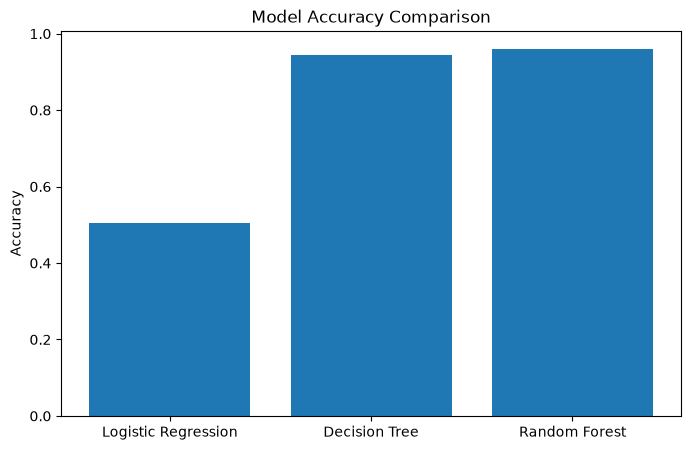

In [41]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    logistic_accuracy,
    tree_accuracy,
    forest_accuracy
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

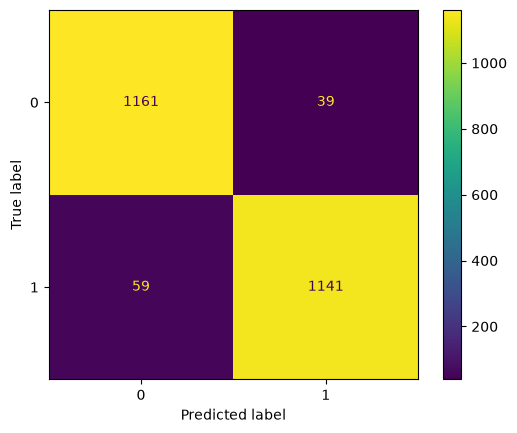

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_forest)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

## Confusion Matrix

The confusion matrix provides a detailed view of classification performance by showing correctly and incorrectly classified instances.

The Random Forest model demonstrates strong performance with a high number of correct predictions in both classes.

In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_forest
    )
)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1200
           1       0.97      0.95      0.96      1200

    accuracy                           0.96      2400
   macro avg       0.96      0.96      0.96      2400
weighted avg       0.96      0.96      0.96      2400



In [44]:
import pandas as pd

feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(
    ascending=False
).head(10)

impressions                0.541277
likes_count                0.161944
shares_count               0.040879
comments_count             0.025120
user_past_sentiment_avg    0.016818
sentiment_score            0.016802
toxicity_score             0.016529
text_content               0.016516
buzz_change_rate           0.016430
keywords                   0.016337
dtype: float64

# Final Conclusion

Three machine learning algorithms were evaluated for social media engagement prediction.

Random Forest achieved the highest accuracy of 95.92%, outperforming Decision Tree (94.29%) and Logistic Regression (50.58%).

The results indicate that social media engagement is influenced by complex non-linear relationships among features, making ensemble tree-based methods more suitable for this task.

Therefore, Random Forest was selected as the final model for deployment and future predictions.